In [1]:
from hems_resopt.components.ev import EV
from res_opt_core import Grid, EnergyModel, AuctionMarket, Load, RenewableProduction, plot_battery_operation, Battery
import pandas as pd
import numpy as np


In [ ]:
import numpy as np
import pandas as pd

# ── Time index: 4 months at 15min resolution ──────────────────────────────────
start_time = pd.Timestamp('2024-01-01 00:00:00', tz='Europe/Zurich')
end_time   = pd.Timestamp('2024-05-01 00:00:00', tz='Europe/Zurich')
time_idx   = pd.date_range(start=start_time, end=end_time, freq='15min', inclusive='left')

hour_of_day  = time_idx.hour + time_idx.minute / 60
day_of_week  = time_idx.dayofweek  # 0=Monday, 6=Sunday
is_weekday   = (day_of_week < 5).astype(float)

# ── PV production ─────────────────────────────────────────────────────────────
# 200 kW peak, only during daylight hours (6:00 - 18:00)
pv_production = np.maximum(
    0, 200 * np.sin(np.pi * (hour_of_day - 6) / 12)
) * (hour_of_day >= 6) * (hour_of_day <= 18)

# ── Building load ─────────────────────────────────────────────────────────────
# Base load: 50 kW always on
# Daytime ramp: peaks around 10:00 and 15:00 on weekdays (production shifts)
# Evening spike: 18:00-20:00 (heating / lighting)
# Random noise to create realistic peaky behaviour
np.random.seed(42)

base_load        = 50.0
morning_peak     = 150 * np.exp(-0.5 * ((hour_of_day - 10.0) / 1.5) ** 2) * is_weekday
afternoon_peak   = 120 * np.exp(-0.5 * ((hour_of_day - 15.0) / 1.5) ** 2) * is_weekday
evening_spike    = 80  * np.exp(-0.5 * ((hour_of_day - 19.0) / 1.0) ** 2)

# Occasional sharp demand spikes (~3x per week) to simulate e.g. compressors/chargers
spike_mask       = np.random.choice([0.0, 1.0], size=len(time_idx), p=[0.995, 0.005])
demand_spikes    = spike_mask * np.random.uniform(100, 250, size=len(time_idx))

# Seasonal scaling: Jan/Feb slightly higher load (heating), Apr lower
month            = time_idx.month
seasonal_factor  = np.where(month <= 2, 1.2,        # Jan-Feb: +20%
                   np.where(month == 3, 1.0,         # Mar: baseline
                            0.85))                   # Apr: -15%

noise            = np.random.normal(0, 8, size=len(time_idx))

load_building = (
    base_load
    + morning_peak
    + afternoon_peak
    + evening_spike
    + demand_spikes
    + noise
) * seasonal_factor

load_building = np.maximum(load_building, 10.0)  # floor at 10 kW

# ── Day-ahead price curve ─────────────────────────────────────────────────────
# Morning and evening price peaks, with some day-to-day variation
daily_variation  = np.random.normal(0, 0.005, size=len(time_idx))
da_price_curve   = (
    0.08
    + 0.04 * np.sin(np.pi * (hour_of_day - 7)  / 6)   # morning peak
    + 0.03 * np.sin(np.pi * (hour_of_day - 18) / 6)   # evening peak
    + daily_variation
)
da_price_curve   = np.maximum(da_price_curve, 0.01)    # floor at 1 ct/kWh

# ── Peak shaving price: constant grid fee ─────────────────────────────────────
# Represents a monthly capacity tariff in CHF/kW
# A flat constant — the optimizer will minimize the monthly peak to reduce this cost
peak_power_price = 15.0  # CHF/kW per month

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df_inputs = pd.DataFrame(
    index=time_idx,
    data={
        'pv_production':  pv_production,
        'load_building':  load_building,
        'da_price_curve': da_price_curve,
        'peak_power_price': peak_power_price,  # constant scalar, same for all steps
    }
)

# reserve market prices
fcr_price_curve = []
afrr_price_curve_d = []
afrr_price_curve_w = []
mfrr_price_curve = []


In [ ]:
from hems_resopt.components.grid import GridPeakShave
from res_opt_core import UnmanagedReserve, ManagedReserve, Imbalance, Afrr, Mfrr
# Set up to test 
model = EnergyModel(
    name='Logistik',
    num_steps=len(df_inputs.index),
    slot_length='15min',
    solver='highs'
)


Building = Load(
    name='Logistik_Zentrum',
    load_curve=df_inputs['load_building'],
    lost_load_allowed=True,
    value_of_lost_load=1000.0
)

battery = Battery(
    name='Shaver',
    power_nominal=100,
    energy_capacity=200
)


DA = AuctionMarket(
    price_curve=df_inputs['da_price_curve'],
    market_time_unit='15min'
)

# Difference between Unmanaged and Managed Reserve Markets is the ability of SoC Management
# Unmanaged is suitable for FCR and Managed more FRR(afrr or mfrr)
# Managed meaning actively securing the SoC to keep it in its boundaries (i.e., Intra-Day trading to keep SoC in its limits)

fcr = UnmanagedReserve(
    name='fcr-market',
    capacity_qualified=80,
    min_bidding_amount=5,
    price_curve=fcr_price_curve,
    market_time_unit='4h_daylight_saving'
)

afrr_d = Afrr(
    name='afrr-market-daily',
    capacity_qualified=100,
    min_bidding_amount=5,
    price_curve=afrr_price_curve_d,
    market_time_unit='4h_daylight_saving'
)

afrr_w = Afrr(
    name='afrr-market-weekly',
    capacity_qualified=100,
    min_bidding_amount=5,
    price_curve=afrr_price_curve_d,
    market_time_unit='weekly' # weekly market time unit is not yet existing, would need to be built
)

#imbalance_market = Imbalance() # Market for trading deviations from positions with consumption and production

markets = [DA, fcr, afrr_w, afrr_d]

grid = GridPeakShave(
    assets=[Building, battery],
    markets=markets,
    # power_max=1000,
    # power_min=-1000,   # physical power line limits
    peak_power_price=100,
    time_horizon_peak='day_naive'
    )

model.add_component(Building)
model.add_component(battery)
model.add_component(grid)
model.add_component(markets)
model.build_and_run(silent=False)

c:\Users\ckw-ThCa\AppData\Local\miniconda3\envs\hems_resopt_new\Lib\site-packages\res_opt_core\core\solver\res_opt_highs_solver.py:17: UserWarning: The 'tee' parameter is not supported by the Highs solver and will be set to None.
  warnings.warn("The 'tee' parameter is not supported by the Highs solver and will be set to None.")


In [33]:
df_results = model.results.timeseries_to_pandas()


# what is the actual load at the meter where peak shaving is conducted? 


In [34]:
df_results['load_meter'] = df_results['Logistik_Zentrum__var_power']+ df_results['Shaver__var_power']

print('load_meter' in df_results.columns)
print(df_results['load_meter'].describe())

True
count    11612.000000
mean       -97.019448
std         57.395677
min       -424.639869
25%       -140.258834
50%        -93.270515
75%        -54.390553
max         77.427708
Name: load_meter, dtype: float64


In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_results(
    df: pd.DataFrame,
    columns: list[str],
    title: str = "Model Results",
    ylabel: str = "Power [kW]",
    figsize: tuple = (14, 5),
    timestamp_col: str = "timestamp",
) -> None:
    """Plots selected columns from a results DataFrame as time series lines.

    Args:
        df: Results DataFrame, typically from model.results.timeseries_to_pandas().
        columns: List of column names to plot.
        title: Title of the plot.
        ylabel: Label for the y-axis.
        figsize: Figure size as (width, height).
        timestamp_col: Name of the timestamp column to use as x-axis.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # use timestamp as x-axis if available, otherwise fall back to integer index
    x = df[timestamp_col] if timestamp_col in df.columns else df.index

    for col in columns:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found in DataFrame — skipping.")
            continue
        ax.plot(x, df[col], label=col, linewidth=1.0)

    # format x-axis as dates if timestamps are available
    if timestamp_col in df.columns:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        fig.autofmt_xdate()

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [36]:
print(df_results.columns.tolist())

['Logistik_Zentrum__var_power', 'Logistik_Zentrum__var_power_reserve_up', 'Logistik_Zentrum__var_power_reserve_down', 'Logistik_Zentrum__var_lost_load', 'Shaver__var_power', 'Shaver__var_power_reserve_up', 'Shaver__var_power_reserve_down', 'Shaver__var_soc_slot_start', 'Shaver__var_soc_slot_end', 'Shaver__var_min_energy_violation', 'Shaver__var_max_energy_violation', 'Shaver__var_power_charge', 'Shaver__var_power_discharge', 'Shaver__var_is_charging', 'Shaver__var_is_discharging', 'Shaver__var_power_max_violation', 'Shaver__var_power_min_violation', 'Shaver__var_energy_reserve_up_slot_start', 'Shaver__var_energy_reserve_down_slot_start', 'Shaver__var_energy_reserve_up_slot_end', 'Shaver__var_energy_reserve_down_slot_end', 'Shaver__var_soc_min_soft_violation', 'Shaver__var_soc_max_soft_violation', 'grid_peak_shave__var_peak_power', 'auction_market__var_power', 'timestamp', 'load_meter']


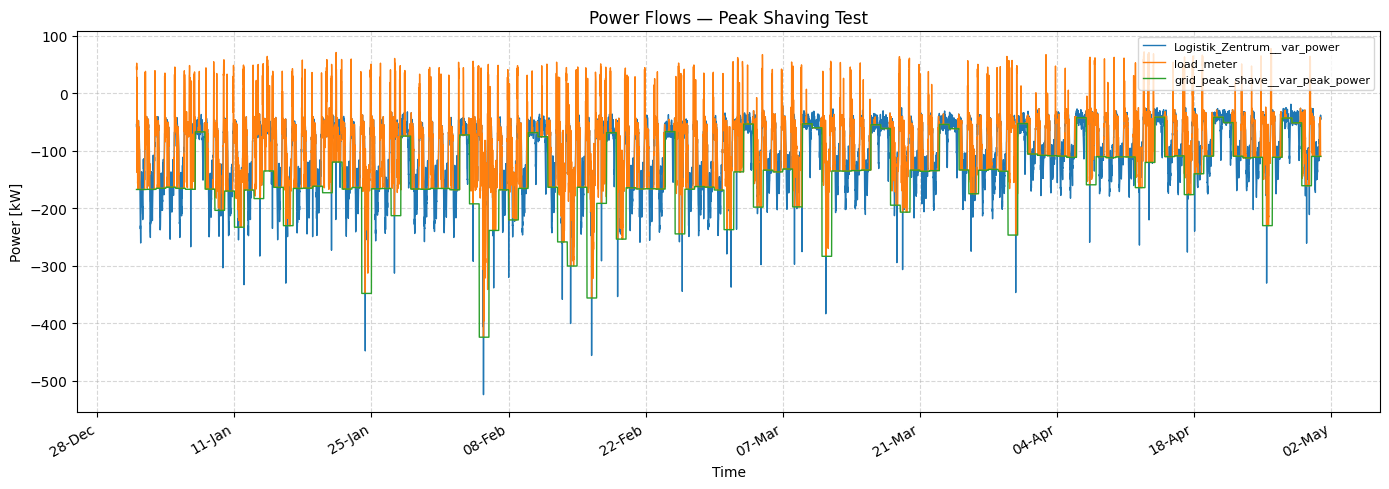

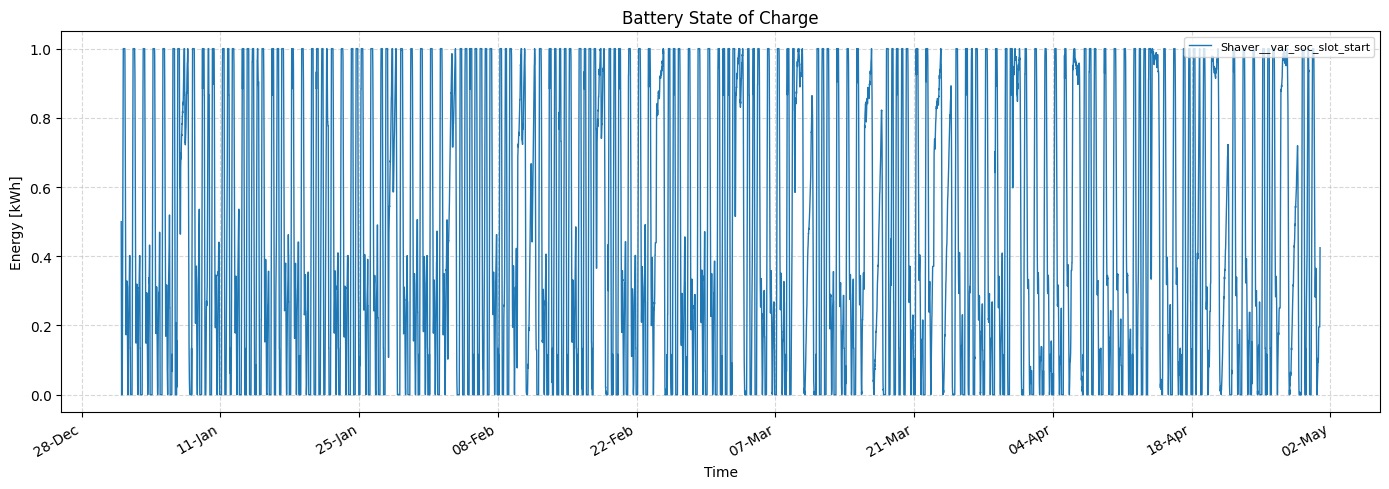

In [37]:


# plot power flows
plot_results(
    df=df_results,
    columns=[
        "Logistik_Zentrum__var_power",
        "load_meter",
        #"Shaver__var_power",
        "grid_peak_shave__var_peak_power",
        #'auction_market__var_power'
    ],
    title="Power Flows — Peak Shaving Test",
    ylabel="Power [kW]",
)

# plot battery SoC separately
plot_results(
    df=df_results,
    columns=["Shaver__var_soc_slot_start"],
    title="Battery State of Charge",
    ylabel="Energy [kWh]",
)
